<a href="https://colab.research.google.com/github/Minnie02/CABON-project/blob/main/omics2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📌 전체 파이프라인

1. raw 데이터 처리

GSE33000, GSE44770 → transcript-level matrix 추출

공통 transcript 기준 맞추기

Combat으로 batch effect 보정 → X (features)

2. series_matrix로 라벨 추출

GSE33000: characteristics_ch2 → "Alzheimer's disease" / "non-demented"

GSE44770: characteristics_ch2 → "A" / "N"

각각 y33000, y44770 벡터 생성 → 병합해서 y

3. X, y 매칭

Combat 보정된 X (샘플 467+230 = 697개)

라벨 y (AD vs Control, 분포 [258, 439] 근처 예상)

이걸 최종 dataset으로 사용

4. 딥러닝 모델 학습

train/val/test 분리

MLP (baseline)

필요 시 CNN, Autoencoder, 앙상블 시도

In [ ]:
# Colab: Google Drive mount
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

In [ ]:
# ============ 1. 데이터 불러오기 ============
df330_raw = pd.read_csv("/content/drive/MyDrive/CABON 주제연구/GSE33000_raw_data.txt.gz", sep="\t", index_col=0)
df447_raw = pd.read_csv("/content/drive/MyDrive/CABON 주제연구/GSE44770_originalDataFile_PFC.txt.gz", sep="\t", index_col=0)

print("GSE33000:", df330_raw.shape)
print("GSE44770:", df447_raw.shape)

GSE33000: (39280, 1250)
GSE44770: (39280, 462)


In [ ]:
df330_raw

,Gene,Transcript,HBTRC_PF_Pool_1,HBTRC_PF_Pool_2,HBTRC_PF_Pool_3,HBTRC_PF_Pool_4,HBTRC_PF_Pool_5,HBTRC_PF_Pool_6,HBTRC_PF_Pool_7,HBTRC_PF_Pool_8,...,PFC_615,PFC_616,PFC_617,PFC_618,PFC_619,PFC_620,PFC_621,PFC_622,PFC_623,PFC_624
reporterID,,,,,,,,,,,,,,,,,,,,,
10019475365,RSE_00000118999,RSE_00000118999,0.399660,0.286885,0.303855,0.259965,0.277602,0.227802,0.209805,0.203077,...,0.9340,1.0100,1.2900,0.6390,0.494,0.6060,0.3760,0.5200,0.5760,0.6250
10019481149,"AGRN,FLJ45064",RSE_00000890695,0.295601,0.309539,0.255890,0.276044,0.224214,0.224626,0.187907,0.190715,...,0.4590,0.5030,0.5160,0.4780,0.305,0.4240,0.3810,0.3640,0.2500,0.4170
10019495284,"HMGB2,HMG2",RSE_00000753518,0.500658,0.448259,0.462672,0.456894,0.453582,0.481320,0.473464,0.432459,...,0.2710,0.2990,0.1820,0.3000,0.275,0.3020,1.7200,0.7030,0.3600,0.2870
10019687586,LOC285706,RSE_00000636266,0.035940,0.038750,0.041836,0.034020,0.039259,0.029540,0.030753,0.023307,...,0.0998,0.0478,0.0412,0.0418,0.035,0.0333,0.0466,0.0324,0.0362,0.0236
10019713746,"DNAH12,DHC3,HL19,DLP12,HL-19,hdhc3,DNAHC3,DNAHC12",RSE_00000772559,0.384949,0.413481,0.359552,0.349322,0.513093,0.291822,0.465031,0.310546,...,1.2600,0.7830,1.8800,1.6500,0.745,0.6130,0.3670,0.5280,0.5460,1.0900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10033669045,"NQO1,DTD,QR1,DHQU,DIA4,NMOR1,NMORI",NM_000903,1.090995,1.133248,1.233704,1.247714,1.216080,0.933760,0.974256,0.994327,...,0.7530,0.5200,0.8800,0.9810,1.190,1.0200,6.0100,1.1800,0.8970,0.6440
10033669046,"ABCG4,WHITE2",NM_022169,0.761209,0.829632,0.797357,0.786179,0.799598,0.755720,0.724680,0.688311,...,0.4130,0.8920,1.0100,0.7890,0.975,1.0000,0.8040,0.7230,0.8130,0.5500
10033669047,"ABCA7,ABCX,ABCA-SSN",NM_019112,0.203756,0.190617,0.205101,0.202310,0.187383,0.225605,0.215693,0.200867,...,0.2140,0.2220,0.2460,0.1380,0.207,0.2190,0.1180,0.1460,0.1800,0.1440


In [ ]:
df447_raw

,transcript,reporterID,HBTRC_1_PFC_Pool,HBTRC_2_PFC_Pool,HBTRC_3_PFC_Pool,HBTRC_4_PFC_Pool,HBTRC_5_PFC_Pool,HBTRC_6_PFC_Pool,HBTRC_7_PFC_Pool,HBTRC_8_PFC_Pool,...,221_PFC,222_PFC,223_PFC,224_PFC,225_PFC,226_PFC,227_PFC,228_PFC,229_PFC,230_PFC
gene,,,,,,,,,,,,,,,,,,,,,
RSE_00000118999,RSE_00000118999,10019475365,0.305708,0.247983,0.481304,0.395275,0.246447,0.188456,0.835905,0.262810,...,0.421505,0.497075,0.295194,0.363305,0.336668,0.288342,0.251460,0.416077,0.573586,0.365780
"AGRN,FLJ45064",RSE_00000890695,10019481149,0.293184,0.278238,0.289262,0.287348,0.193444,0.159265,0.520779,0.169311,...,0.301509,0.322730,0.283825,0.276048,0.281638,0.297413,0.241825,0.308339,0.333838,0.253137
"HMGB2,HMG2",RSE_00000753518,10019495284,0.391546,0.540140,0.326468,0.443064,0.403324,0.398373,0.177835,0.350942,...,0.421229,0.399941,0.344251,0.439263,0.434519,0.380299,0.398140,0.435961,0.371150,0.350565
LOC285706,RSE_00000636266,10019687586,0.041801,0.031527,0.049598,0.040137,0.035057,0.036336,0.029724,0.031193,...,0.034948,0.025501,0.050709,0.032046,0.035888,0.037009,0.049243,0.042409,0.041349,0.035206
"DNAH12,DHC3,HL19,DLP12,HL-19,hdhc3,DNAHC3,DNAHC12",RSE_00000772559,10019713746,0.445598,0.341132,0.580758,0.364179,0.593288,0.409158,1.234819,0.416257,...,0.512656,0.563988,0.434169,0.342972,0.450904,0.480443,0.338093,0.452980,0.420356,0.249898
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
"NQO1,DTD,QR1,DHQU,DIA4,NMOR1,NMORI",NM_000903,10033669045,0.683442,1.073083,0.604157,0.727590,0.999484,1.180978,0.959354,3.202112,...,1.109204,1.144202,0.988062,1.121745,1.403852,1.170319,0.845186,1.203181,1.065977,NaN
"ABCG4,WHITE2",NM_022169,10033669046,0.827689,0.845787,0.866598,0.802318,0.853863,0.544138,0.819163,0.325516,...,0.883542,0.898196,0.730938,0.813642,0.790889,0.820588,0.709956,0.776192,0.703815,0.758588
"ABCA7,ABCX,ABCA-SSN",NM_019112,10033669047,0.172676,0.185417,0.152326,0.148493,0.152665,0.331298,0.178441,0.333547,...,0.195735,0.223799,0.200772,0.215204,0.195751,0.203271,0.193943,0.158896,0.161089,0.175954


In [ ]:
# === 1. GSE33000 ===
expr_cols330 = [c for c in df330_raw.columns if "PFC" in c or "Pool" in c]
df330_tx = df330_raw.set_index("Transcript")[expr_cols330]
df330_tx = df330_tx.groupby(df330_tx.index).mean()  # 중복 transcript 처리

print("GSE33000 Transcript-level:", df330_tx.shape)

# === 2. GSE44770 ===
expr_cols447 = [c for c in df447_raw.columns if "PFC" in c or "Pool" in c]
df447_tx = df447_raw.set_index("transcript")[expr_cols447]
df447_tx = df447_tx.groupby(df447_tx.index).mean()

print("GSE44770 Transcript-level:", df447_tx.shape)

# === 3. 공통 Transcript 추출 ===
common_tx = df330_tx.index.intersection(df447_tx.index)
df330_tx = df330_tx.loc[common_tx]
df447_tx = df447_tx.loc[common_tx]

print("Common Transcripts:", len(common_tx))
print("GSE33000 aligned:", df330_tx.shape)
print("GSE44770 aligned:", df447_tx.shape)


GSE33000 Transcript-level: (38853, 1248)
GSE44770 Transcript-level: (38853, 460)
Common Transcripts: 38853
GSE33000 aligned: (38853, 1248)
GSE44770 aligned: (38853, 460)


In [ ]:
# !pip install neuroCombat

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from neuroCombat import neuroCombat

# Transcript 기준 매트릭스
expr_cols330 = [c for c in df330_raw.columns if "PFC" in c or "Pool" in c]
expr_cols447 = [c for c in df447_raw.columns if "PFC" in c or "Pool" in c]

df330_tx = df330_raw.set_index("Transcript")[expr_cols330].groupby("Transcript").mean()
df447_tx = df447_raw.set_index("transcript")[expr_cols447].groupby("transcript").mean()

# 교집합 Transcript
common_tx = df330_tx.index.intersection(df447_tx.index)
df330_tx = df330_tx.loc[common_tx]
df447_tx = df447_tx.loc[common_tx]

# === 2. 합치기 ===
all_expr = pd.concat([df330_tx, df447_tx], axis=1)

# === 3. batch 정보 ===
batch = np.array([0]*df330_tx.shape[1] + [1]*df447_tx.shape[1])

# === 4. neuroCombat 보정 ===
combat_result = neuroCombat(
    dat=all_expr,                # gene × samples (DataFrame)
    covars=pd.DataFrame({"batch": batch}),
    batch_col="batch"
)

combat_expr = pd.DataFrame(
    combat_result["data"],
    index=all_expr.index,
    columns=all_expr.columns
)

print("Combat corrected:", combat_expr.shape)

# === 5. Scaling ===
scaler = StandardScaler()
X = scaler.fit_transform(combat_expr.T)   # samples × features


[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
Combat corrected: (38853, 1708)


/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


In [ ]:
# === NaN 처리 (열 평균 기준) ===
print("보정 전 결측치 개수:", all_expr.isna().sum().sum())

# 각 열(샘플)별 평균으로 NaN 대체
all_expr = all_expr.fillna(all_expr.mean(axis=0))

print("보정 후 결측치 개수:", all_expr.isna().sum().sum())

# === Combat 실행 ===
combat_result = neuroCombat(
    dat=all_expr,
    covars=pd.DataFrame({"batch": batch}),
    batch_col="batch"
)

combat_expr = pd.DataFrame(
    combat_result["data"],
    index=all_expr.index,
    columns=all_expr.columns
)

print("Combat corrected shape:", combat_expr.shape)
print(combat_expr.iloc[:5, :5])


보정 전 결측치 개수: 844622
보정 후 결측치 개수: 0
[neuroCombat] Creating design matrix
[neuroCombat] Standardizing data across features
[neuroCombat] Fitting L/S model and finding priors
[neuroCombat] Finding parametric adjustments
[neuroCombat] Final adjustment of data
Combat corrected shape: (38853, 1708)
          HBTRC_PF_Pool_1  HBTRC_PF_Pool_2  HBTRC_PF_Pool_3  HBTRC_PF_Pool_4  \
AA019935         1.510354         1.870769         1.675814         1.825813   
AA063406         0.016221         0.000790         0.012087         0.001449   
AA079026         0.036477         0.033310         0.013555         0.001684   
AA082669        16.054757        16.567049        16.475142        19.311960   
AA083497         1.883274         1.726865         1.400751         1.613483   

          HBTRC_PF_Pool_5  
AA019935         1.774476  
AA063406         0.012202  
AA079026         0.015136  
AA082669        20.678727  
AA083497         1.683634  


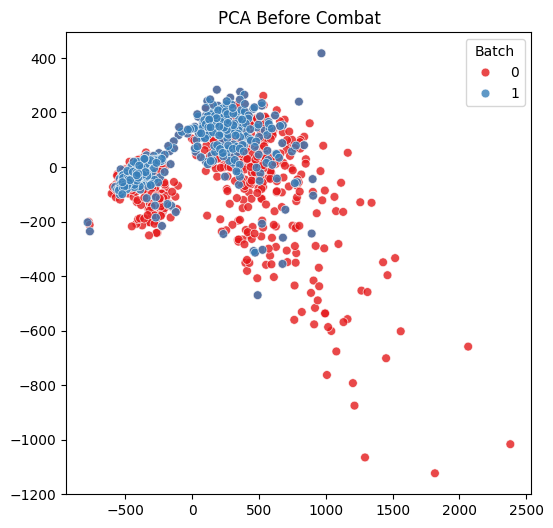

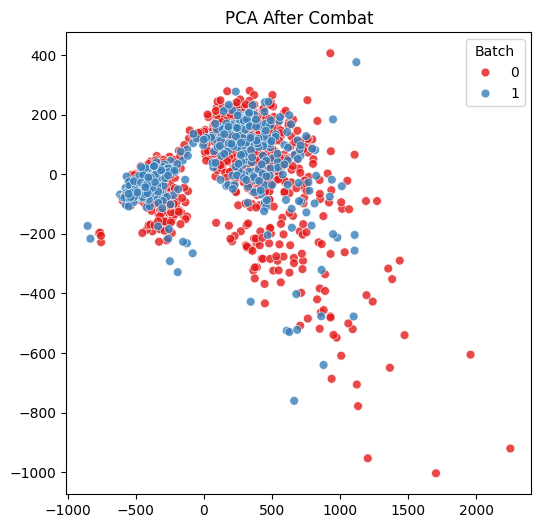

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

def plot_pca(data, labels, title):
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(data.T)  # samples × features
    plt.figure(figsize=(6,6))
    sns.scatterplot(
        x=pca_result[:,0], y=pca_result[:,1],
        hue=labels, palette="Set1", s=40, alpha=0.8
    )
    plt.title(title)
    plt.legend(title="Batch")
    plt.show()

# 보정 전 PCA
plot_pca(all_expr, batch, "PCA Before Combat")

# 보정 후 PCA
plot_pca(combat_expr, batch, "PCA After Combat")


In [ ]:
import gzip
import numpy as np

series_path = "/content/drive/MyDrive/CABON 주제연구/GSE44770_series_matrix.txt.gz"

labels = []
with gzip.open(series_path, "rt") as f:
    for line in f:
        if line.startswith("!Sample_characteristics_ch2") and "disease" in line.lower():
            labels = line.strip().split("\t")[1:]  # 첫 번째 칼럼 제거
            break

print("원시 라벨 예시:", labels[:10])

# Alzheimer = 1, Control = 0
y = np.array([1 if "alzheimer" in l.lower() else 0 for l in labels])
print("라벨 분포:", np.bincount(y))


원시 라벨 예시: ['"disease: A"', '"disease: A"', '"disease: N"', '"disease: N"', '"disease: A"', '"disease: A"', '"disease: N"', '"disease: A"', '"disease: N"', '"disease: A"']
라벨 분포: [230]


In [ ]:
import gzip, re, pandas as pd, numpy as np

def load_expr_and_labels(series_path, dataset):
    """
    GEO series_matrix를 불러와 발현행렬(expr)과 라벨(y)을 반환.
    dataset = "GSE33000" 또는 "GSE44770"
    """
    # ==== 1. 발현행렬 ====
    expr = pd.read_csv(series_path, sep="\t", comment="!", index_col=0, compression="gzip")

    # ==== 2. 메타데이터 전체 파싱 ====
    rows, order = {}, []
    with gzip.open(series_path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            if line.startswith("!Sample_"):
                parts = line.rstrip("\n").split("\t")
                rows[parts[0]] = [v.strip().strip('"') for v in parts[1:]]
                order.append(parts[0])
    keys = list(dict.fromkeys(order))
    maxlen = max(len(v) for v in rows.values())
    meta = pd.DataFrame({k:(rows.get(k,[])+[""]*(maxlen-len(rows.get(k,[])))) for k in keys})
    meta = meta.rename(columns=lambda c: re.sub(r"^!Sample_","",c))

    # ==== 3. 데이터셋별 처리 ====
    if dataset == "GSE33000":
        # disease 정보는 ch2에 있음
        labels = pd.Series(meta["characteristics_ch2"]).str.replace(r"^[^:]+:\s*","",regex=True).str.strip()
        lab = pd.DataFrame({"gsm": meta["geo_accession"], "label": labels})
        lab["label"] = lab["label"].replace({
            "Alzheimer's disease":"AD",
            "non-demented":"Control",
            "control":"Control"
        })
        # GSM 기준으로 매칭
        cols = [c for c in expr.columns if c in set(lab["gsm"])]
        expr = expr[cols]
        lab = lab.set_index("gsm").loc[cols].reset_index()
        mask = lab["label"].isin(["AD","Control"])
        expr = expr.loc[:, mask.values]
        y = lab.loc[mask, "label"].map({"AD":1, "Control":0}).astype(int).values

    elif dataset == "GSE44770":
        # disease 정보는 ch2에 있음
        labels = []
        with gzip.open(series_path, "rt", encoding="utf-8", errors="ignore") as f:
            for line in f:
                if line.startswith("!Sample_characteristics_ch2") and "disease" in line.lower():
                    parts = line.strip().split("\t")[1:]
                    labels = [re.sub(r"^.*:\s*", "", p.strip().strip('"')) for p in parts]
                    break
        # A/N → AD/Control
        labels = ["AD" if l=="A" else "Control" for l in labels]
        y = np.array([1 if l=="AD" else 0 for l in labels], dtype=int)
        # expr 열 순서와 그대로 매칭
        expr = expr.iloc[:, :len(y)]

    else:
        raise ValueError("dataset은 'GSE33000' 또는 'GSE44770'만 지원합니다.")

    return expr, y


In [ ]:
path_33000 = "/content/drive/MyDrive/CABON 주제연구/GSE33000_series_matrix.txt.gz"
path_44770 = "/content/drive/MyDrive/CABON 주제연구/GSE44770_series_matrix.txt.gz"

expr33000, y33000 = load_expr_and_labels(path_33000, "GSE33000")
expr44770, y44770 = load_expr_and_labels(path_44770, "GSE44770")

print("GSE33000:", expr33000.shape, np.bincount(y33000))
print("GSE44770:", expr44770.shape, np.bincount(y44770))


GSE33000: (39280, 467) [157 310]
GSE44770: (39280, 230) [101 129]


In [ ]:
# === 라벨 병합 ===
y = np.concatenate([y33000, y44770])
print("통합 라벨 분포:", np.bincount(y), "| 길이:", len(y))

통합 라벨 분포: [258 439] | 길이: 697


In [ ]:
import gzip

def extract_gsm_to_pool_from_soft(soft_path):
    gsm_to_pool = {}
    gsm, pool = None, None
    with gzip.open(soft_path, "rt", encoding="utf-8", errors="ignore") as f:
        for line in f:
            line = line.strip()
            if line.startswith("!Sample_title"):
                pool = line.split("=")[1].strip()   # e.g. 1_PFC
            elif line.startswith("!Sample_geo_accession"):
                gsm = line.split("=")[1].strip()   # e.g. GSM1090501
                if gsm and pool:
                    gsm_to_pool[gsm] = pool
                    gsm, pool = None, None         # 리셋
    return gsm_to_pool

map44770 = extract_gsm_to_pool_from_soft("/content/drive/MyDrive/CABON 주제연구/GSE44770_family.soft.gz")
print("총 매핑 수:", len(map44770))
print(list(map44770.items())[:10])


총 매핑 수: 230
[('GSM1090501', '1_PFC'), ('GSM1090502', '2_PFC'), ('GSM1090503', '3_PFC'), ('GSM1090504', '4_PFC'), ('GSM1090505', '5_PFC'), ('GSM1090506', '6_PFC'), ('GSM1090507', '7_PFC'), ('GSM1090508', '8_PFC'), ('GSM1090509', '9_PFC'), ('GSM1090510', '10_PFC')]


In [ ]:
X = np.concatenate([expr33000.T.values, expr44770.T.values], axis=0)  # 샘플 × 유전자
y = np.concatenate([y33000, y44770])                       # 라벨 벡터
print("X:",X.shape, "y:",y.shape)

X: (697, 39280) y: (697,)


In [ ]:
# Combat 이후 NaN 확인
print("Combat NaN 개수:", combat_expr.isna().sum().sum())

# Combat 이후 NaN → 열 평균 대체
combat_expr = combat_expr.fillna(combat_expr.mean(axis=0))

print("Combat NaN 처리 후:", combat_expr.isna().sum().sum())


Combat NaN 개수: 0
Combat NaN 처리 후: 0


In [ ]:
# === 1. 데이터 분할 ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# === 2. Scaling ===
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

# 분산 0 feature → NaN 발생 가능 → 다시 안전 처리
X_train = np.nan_to_num(X_train, nan=0.0, posinf=0.0, neginf=0.0)
X_test  = np.nan_to_num(X_test, nan=0.0, posinf=0.0, neginf=0.0)

# Torch tensor 변환
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=32, shuffle=True)
test_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=32, shuffle=False)

In [ ]:
# === 3. MLP 모델 정의 ===
class MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2)
        )
    def forward(self, x):
        return self.net(x)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = MLP(X_train.shape[1]).to(device)

# === 4. 학습 ===
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

epochs = 20
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        preds = model(xb)
        loss = criterion(preds, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/len(train_loader):.4f}")

# === 5. 평가 ===
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        preds = model(xb)
        y_pred.extend(preds.argmax(1).cpu().numpy())
        y_true.extend(yb.numpy())

Epoch 1/20, Loss: 1.0011
Epoch 2/20, Loss: 1.1369
Epoch 3/20, Loss: 0.3483
Epoch 4/20, Loss: 0.2234
Epoch 5/20, Loss: 0.1910
Epoch 6/20, Loss: 0.1670
Epoch 7/20, Loss: 0.0647
Epoch 8/20, Loss: 0.0782
Epoch 9/20, Loss: 0.1527
Epoch 10/20, Loss: 0.1505
Epoch 11/20, Loss: 0.0315
Epoch 12/20, Loss: 0.1147
Epoch 13/20, Loss: 0.0937
Epoch 14/20, Loss: 0.0317
Epoch 15/20, Loss: 0.0163
Epoch 16/20, Loss: 0.0279
Epoch 17/20, Loss: 0.0371
Epoch 18/20, Loss: 0.0467
Epoch 19/20, Loss: 0.0103
Epoch 20/20, Loss: 0.0567



Classification Report:
               precision    recall  f1-score   support

     Control       0.94      0.94      0.94        52
          AD       0.97      0.97      0.97        88

    accuracy                           0.96       140
   macro avg       0.95      0.95      0.95       140
weighted avg       0.96      0.96      0.96       140



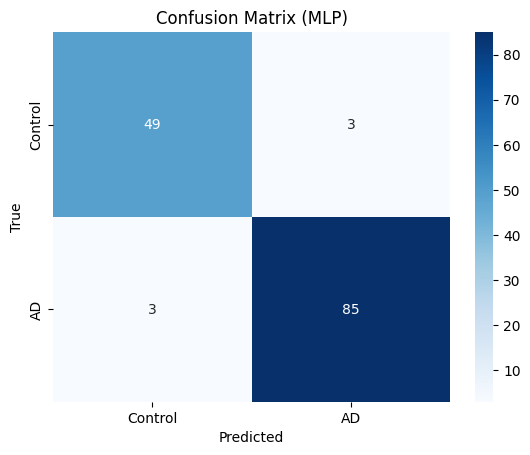

In [ ]:
# === 6. 결과 출력 ===
print("\nClassification Report:\n", classification_report(y_true, y_pred, target_names=["Control","AD"]))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Control","AD"], yticklabels=["Control","AD"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix (MLP)")
plt.show()